In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('/Users/muhammadnehal/Desktop/mindlens/datasets/text/mindlens_text_dataset.csv')

In [6]:
data.head()

,text,target
0,I'm almost at a breaking point...New Year's Ev...,1
1,There’s no joy leftI spent too much of my life...,1
2,I often cut myself. But of sanity not sadnessI...,1
3,Please just someone talk to meI'm crying and o...,1
4,Little do my friends know that they are the on...,0


In [7]:
data.shape

(239805, 2)

In [8]:
data.isnull().sum()

text      0
target    0
dtype: int64

In [9]:
data = data[data["text"].str.len() > 20]

In [10]:
data.shape

(239143, 2)

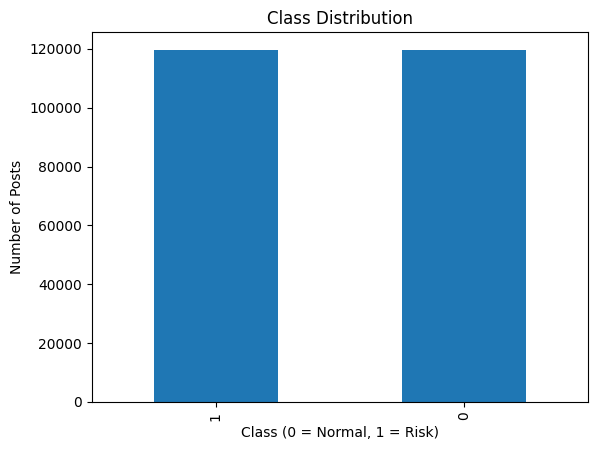

In [11]:
data["target"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Risk)")
plt.ylabel("Number of Posts")

plt.show()

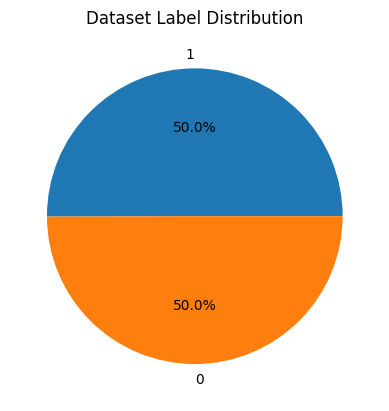

In [12]:
data["target"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Dataset Label Distribution")

plt.ylabel("")
plt.show()

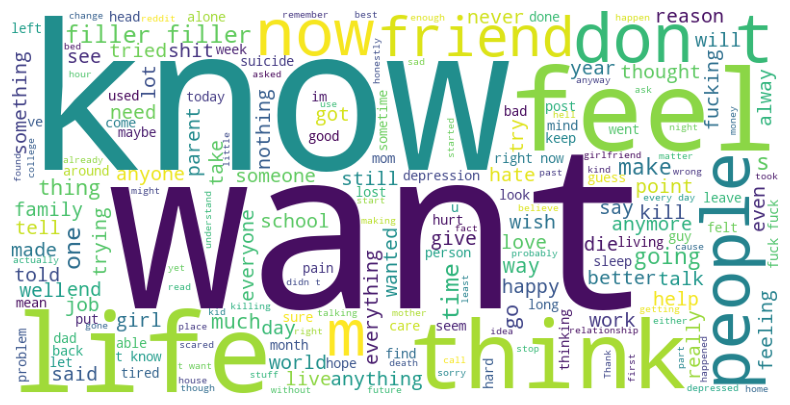

In [13]:
from wordcloud import WordCloud

text = " ".join(data["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

plt.show()

In [14]:
data["text_length"] = data["text"].apply(len)
data["word_count"] = data["text"].apply(lambda x: len(x.split()))

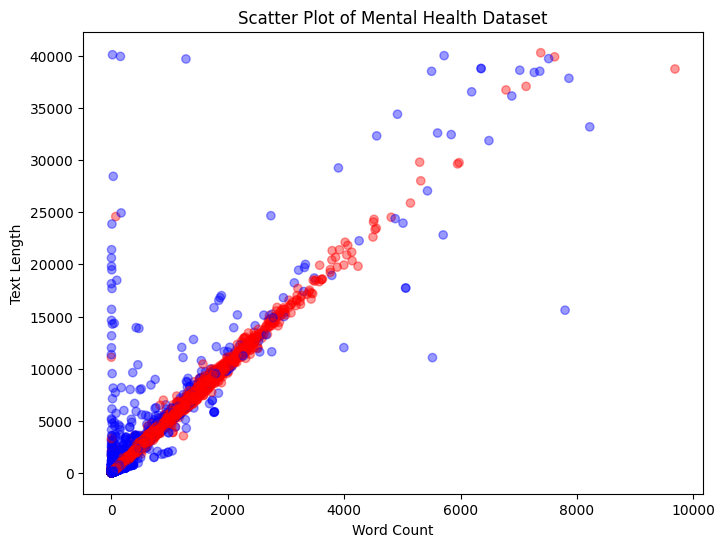

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

colors = data["target"].map({0:"blue",1:"red"})

plt.scatter(
    data["word_count"],
    data["text_length"],
    c=colors,
    alpha=0.4
)

plt.xlabel("Word Count")
plt.ylabel("Text Length")
plt.title("Scatter Plot of Mental Health Dataset")

plt.show()

TEXT CLEANING

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



In [18]:
nltk.download("stopwords")
nltk.download("punkt")

# stop_words = set(stopwords.words("english"))

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


False

Certification error occured and took help from ChatGPT to solve.

In [19]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/muhammadnehal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/muhammadnehal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [20]:
stop_words = set(stopwords.words("english"))

In [21]:
data.head()

,text,target,text_length,word_count
0,I'm almost at a breaking point...New Year's Ev...,1,236,46
1,There’s no joy leftI spent too much of my life...,1,550,110
2,I often cut myself. But of sanity not sadnessI...,1,329,66
3,Please just someone talk to meI'm crying and o...,1,198,34
4,Little do my friends know that they are the on...,0,955,196


In [22]:
data = data.drop('text_length',axis=1)
data = data.drop('word_count',axis=1)

In [23]:
data.head()

,text,target
0,I'm almost at a breaking point...New Year's Ev...,1
1,There’s no joy leftI spent too much of my life...,1
2,I often cut myself. But of sanity not sadnessI...,1
3,Please just someone talk to meI'm crying and o...,1
4,Little do my friends know that they are the on...,0


In [24]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

In [25]:
nltk.download('punkt_tab')
data["clean_text"] = data["text"].apply(clean_text)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/muhammadnehal/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [26]:
data.head()

,text,target,clean_text
0,I'm almost at a breaking point...New Year's Ev...,1,im almost breaking pointnew years eve alone ag...
1,There’s no joy leftI spent too much of my life...,1,theres joy lefti spent much life trying enjoy ...
2,I often cut myself. But of sanity not sadnessI...,1,often cut sanity sadnessi often cut see much p...
3,Please just someone talk to meI'm crying and o...,1,please someone talk meim crying overwhelmed ev...
4,Little do my friends know that they are the on...,0,little friends know reason havent killed every...


In [27]:
data = data.drop("text", axis=1)

In [28]:
data.head()

,target,clean_text
0,1,im almost breaking pointnew years eve alone ag...
1,1,theres joy lefti spent much life trying enjoy ...
2,1,often cut sanity sadnessi often cut see much p...
3,1,please someone talk meim crying overwhelmed ev...
4,0,little friends know reason havent killed every...


TRAIN/TEST SPLIT

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X = data["clean_text"]
y = data["target"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

TF-IDF VECTORIZER

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
vectorizer = TfidfVectorizer(max_features=10000)

In [34]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Training Model

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
model = LogisticRegression(max_iter=200)

In [37]:
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

EVALUATION

In [38]:
from sklearn.metrics import classification_report

In [39]:
preds = model.predict(X_test_vec)

In [40]:
print(preds)

[0 0 0 ... 0 0 0]


In [41]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     23903
           1       0.94      0.93      0.93     23926

    accuracy                           0.93     47829
   macro avg       0.93      0.93      0.93     47829
weighted avg       0.93      0.93      0.93     47829



In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, preds)

In [43]:
print(accuracy)

0.9339103890944824


In [47]:
import pickle

In [48]:
# Test sentence
text = ["I feel hopeless and tired of everything in my life"]

In [49]:
# Transform text
text_vec = vectorizer.transform(text)

In [50]:
# Predict
prediction = model.predict(text_vec)

In [51]:
print('prediction :',prediction)

prediction : [1]


In [52]:
if prediction[0] == 1:
    print("Mental health risk detected")
else:
    print("Normal text")

Mental health risk detected


Saving the Model and Vectorizer

To use the trained model and the TF-IDF vectorizer later for new predictions, we need to save them. The pickle library in Python allows us to serialize and deserialize Python objects.

In [53]:
import pickle

# Save the trained model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Logistic Regression model saved as 'logistic_regression_model.pkl'")

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)
print("TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'")

Logistic Regression model saved as 'logistic_regression_model.pkl'
TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'
